# Stereo using OpenCV

Your name: James Bishop

Your ID number: 9117504

In the last assignments, we looked at sparse reconstruction. We extracted a small set of ORB features from the image, we estimated the essential matrix, and we reconstructed the 3D points.

It's quite natural to wonder, though, if we are not dumping too much information when we only take sparse data points. Can we not use all the pixels of the image? Of course, this is where stereo comes in.

In this Notebook, we will take a look at stereo rectification, disparity and depth estimation, using OpenCV.

We are going to use the (relayively) famous [KITTI Vision Benchmark Suite](https://www.cvlibs.net/datasets/kitti/). It's worth heading over to that site to have a look around - loads of nice datasets there. We're just going to take one stereo image pair.

In this activity, I will give you a lot of the code. The OpenCV interfaces can be a bit awkward to use. You will write soem code, and answer lots of questions.

## Read the images and the calibration

Let's start by reading the two images.

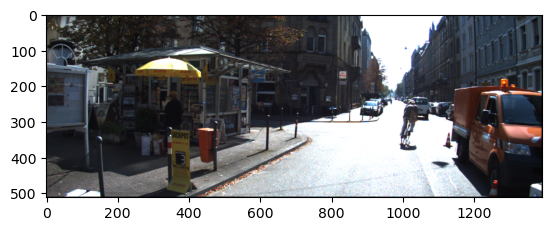

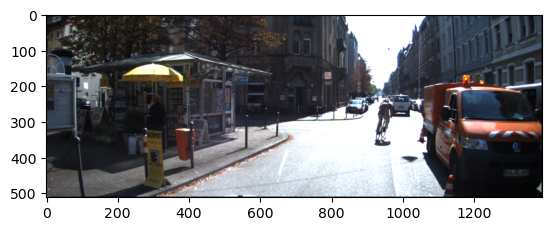

In [24]:
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

# We will read both a colour version and a gray version. The colour version we will use for drawing stuff on,
# and the gray for the processing
imgL_color = cv2.imread('kitti_left_02.png')
imgR_color = cv2.imread('kitti_right_03.png')

imgL_color = cv2.cvtColor(imgL_color, cv2.COLOR_BGR2RGB)
imgR_color = cv2.cvtColor(imgR_color, cv2.COLOR_BGR2RGB)

imgL = cv2.imread('kitti_left_02.png',cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread('kitti_right_03.png',cv2.IMREAD_GRAYSCALE)

plt.figure()
plt.imshow(imgL_color,cmap='gray')
plt.figure()
plt.imshow(imgR_color,cmap='gray')

The KITTI vehicle set up - note the stereo camera rig on top of the vehicle.

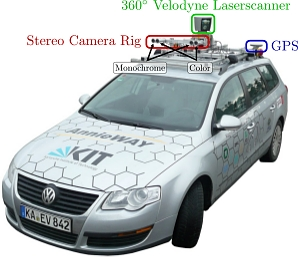

Now let's get the calibration info. This is just extracted from the KITTI datasets.

In [25]:
import numpy as np

# Distortion parameters, per the OpenCV model (this is 3 radial distortion parameters and two tangential distortion parameters)
dist_l = np.array([-3.691481e-01, 1.968681e-01, 1.353473e-03,  5.677587e-04, -6.770705e-02])
dist_r = np.array([-3.639558e-01, 1.788651e-01, 6.029694e-04, -3.922424e-04, -5.382460e-02])

# The instrinsic camera matrices for the two cameras
K_l = np.array([[ 959.791, 0       , 696.0217 ],
                [ 0      , 956.9251, 224.1806 ],
                [ 0      , 0       , 1        ]])                   
K_r = np.array([[ 903.7596, 0       , 695.7519 ],
                [ 0       , 901.9653, 224.2509 ],
                [ 0       , 0       , 1        ]])

# The camera positions are defined in a global reference frame, so they have separate rotation and position
R_l = np.array([[  0.999975800, -0.005267463, -0.004552439 ],
                [  0.005251945,  0.999980400, -0.003413835 ],
                [  0.004570332,  0.003389843,  0.999838000 ]])                   
R_r = np.array([[  0.999559900,  0.016995220, -0.024313130 ],
                [ -0.017044220,  0.999853100, -0.001809756 ],
                [  0.024278800,  0.002223358,  0.999702800 ]])

t_l = np.array([  0.05956621, 0.0002900141,  0.002577209 ])
t_r = np.array([ -0.47310500, 0.0055514700, -0.005250882 ])

# For subsequent processing, we need the RELATIVE positions of the cameras
# R is the orientation of the right camera in the reference frame of the left camera
# And t is the position of the right camera in the reference frame of the left camera
R = R_l.T @ R_r
t = R_l.T @ (t_r - t_l)

# The image shape
h, w = imgL.shape[:2]

## Do the stereo rectification

Now we will use OpenCV to do the rectification. The first step is to define the rectification parameters, i.e. the new camera matrices. It's worth having a look at the `cv2.stereoRectify`

In [26]:
R1, R2, P1, P2, Q, roi1, roi2 = cv2.stereoRectify(K_l, dist_l, K_r, dist_r, (w, h), R, t, 
                                                  cv2.CALIB_ZERO_DISPARITY, 0, (w, h),alpha=0)

<font color='blue'>

#### Task

Print the camera matrices `P1` and `P2` that are output from the `stereoRectify` function above.

In [27]:
##################################
# Your code here
"""print(K_l)
print('\n')
print(K_r)
print('\n')"""
print(P1)
print('\n')
print(P2)





[[972.82072754   0.         694.91941071   0.        ]
 [  0.         972.82072754 208.83206558   0.        ]
 [  0.           0.           1.           0.        ]]


[[ 972.82072754    0.          694.91941071 -518.27483076]
 [   0.          972.82072754  208.83206558    0.        ]
 [   0.            0.            1.            0.        ]]


<font color='blue'>

#### Questions
    
**Question**: Describe the new projection matrices. What can you say about the intrinsics (particularly, compared to the input intrinsics in `K_l` and `K_r`)? Is there a relative rotation and/or translation between the new projection matrices?

Both P1 and P2 share the same f, cx, and cy — a single common intrinsic matrix. This is in contrast to K_l and K_r, which have different focal lengths (K_l: fx=959.8, fy=956.9 vs K_r: fx=903.8, fy=901.97) and slightly different principal points.

<font color='blue'>

**Question**: Given the projection matrices above, can you estimate the physical distance between the cameras? The final unit would be in metres.

P1 places the left camera at the origin and the right camera at the offset. t is the position of the right camera in the reference frame of the left camera. We are given the formula t = R_l.T @ (t_r - t_l) for the position of the right camera. The physical distance between the cameras is estimated in the code cell below.

In [28]:
#Calculate t vector from left rotation matrix and translation vector
t = -np.dot(R_l.T, (t_r-t_l))
print("Translation Vector t:")
print(t)
print("The distance between the two cameras is given by the norm of the translation vector t:")
t_norm = np.linalg.norm(t)
print(f"It has been calculated as {t_norm:.2f} metres")

Translation Vector t:
[ 0.53266646 -0.00804064  0.00541983]
The distance between the two cameras is given by the norm of the translation vector t:
It has been calculated as 0.53 metres


### Now actually rectify the images

Now we will actually transform the images according to the new projection matrices above. That is, we will create the stereo image pair.

In [29]:
# The first step is to create the maps for the rectification. This function returns a
# Look-Up-Table that can be subsequently used to do the mapping to the new image.
map1x, map1y = cv2.initUndistortRectifyMap(K_l, dist_l, R1, P1, (w, h), cv2.CV_32FC1)
map2x, map2y = cv2.initUndistortRectifyMap(K_r, dist_r, R2, P2, (w, h), cv2.CV_32FC1)

# Let's then remap the image. We will do this for both the color and the gray images
imgL_rColor = cv2.remap(imgL_color, map1x, map1y, cv2.INTER_LINEAR)
imgR_rColor = cv2.remap(imgR_color, map2x, map2y, cv2.INTER_LINEAR)
imgL_rGray = cv2.remap(imgL, map1x, map1y, cv2.INTER_LINEAR, cv2.BORDER_ISOLATED)
imgR_rGray = cv2.remap(imgR, map2x, map2y, cv2.INTER_LINEAR, cv2.BORDER_ISOLATED)

<font color='blue'>

#### Task

Plot a set of horizontal lines across both resulting images (`imgL_rColor` and `imgR_rColor`) at the same height. We know that these are now epipolar lines - that is the goal of the rectfication process.

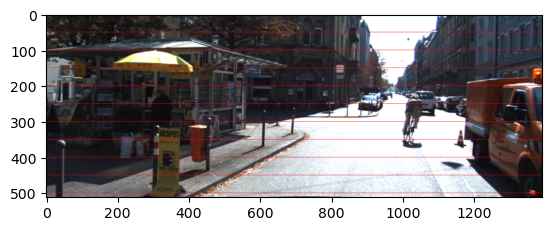

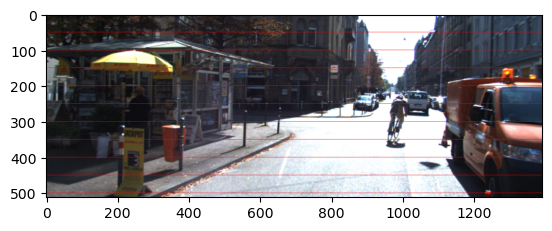

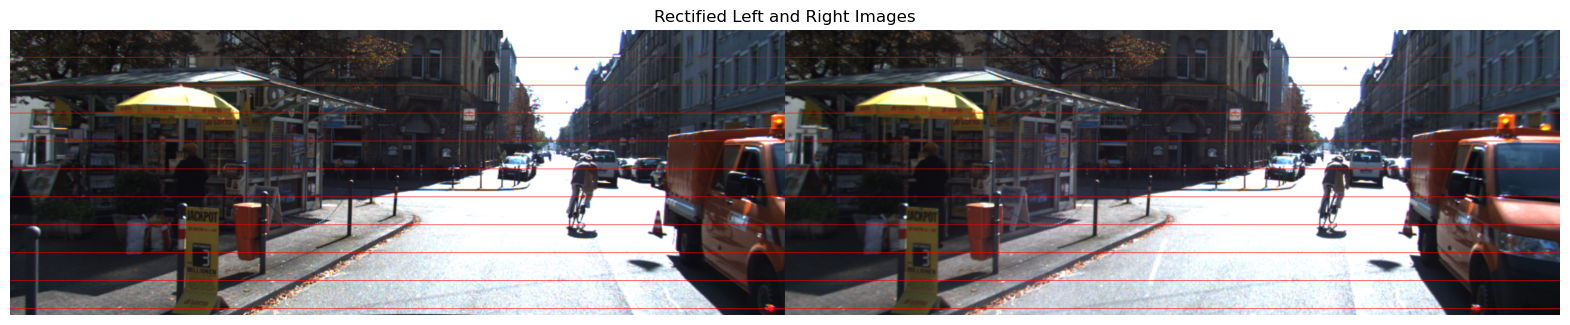

In [37]:
##################################
# Your code here
for y in range(0, h, 50):
    cv2.line(imgL_rColor, (0, y), (w, y), (255, 0, 0), 1)
    cv2.line(imgR_rColor, (0, y), (w, y), (255, 0, 0), 1)
plt.figure()
plt.imshow(imgL_rColor)
plt.figure()
plt.imshow(imgR_rColor)

#Display left and right rectified images side by side
img_combined = np.hstack((imgL_rColor, imgR_rColor))
plt.figure(figsize=(20, 10))
plt.imshow(img_combined)
plt.title('Rectified Left and Right Images')
plt.axis('off')
plt.show()

<font color='blue'>

#### Questions
    
**Question**: Describe what you see with the horizontal lines. Does it look like the stereo rectification did a good job? Explain

The horizontal lines are identical in number (10) and, when printed side by side, are seen to be identical in position in the y-axis direction. This means that ponts on the left image lie on the same horizontal scan line in the right image. This proves that the task of rectification has been carried out correctly.

### Compute the disparity

We will use OpenCV to create the disparity for the image pair.

There are two parameters. `numDisparities` is the maximum disparity size/distance. `blockSize` is the size of the kernel for the stereo block matching.

We have some parameters set below, but this doesn't look great.

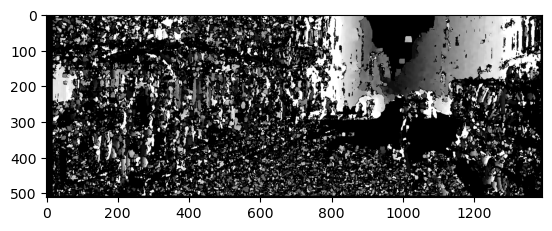

In [53]:
stereo = cv2.StereoBM.create(numDisparities=16, blockSize=9)
disparity = stereo.compute(imgL_rGray, imgR_rGray)
plt.imshow(disparity,'gray')
plt.show()

<font color='blue'>
    
#### Task:
The disparity above is not very good. Copy the code a few times, and play with the parameters to see if you can make it better.

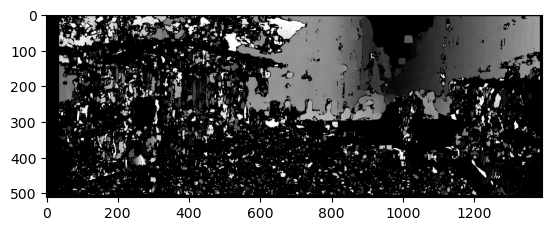

In [39]:
##################################
# Your code here
stereo = cv2.StereoBM.create(numDisparities=32, blockSize=13)
disparity = stereo.compute(imgL_rGray, imgR_rGray)
plt.imshow(disparity,'gray')
plt.show()

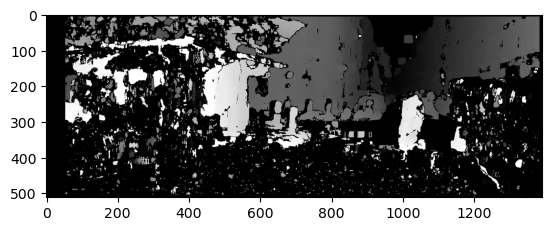

In [40]:
##################################
# Your code here
stereo = cv2.StereoBM.create(numDisparities=48, blockSize=15)
disparity = stereo.compute(imgL_rGray, imgR_rGray)
plt.imshow(disparity,'gray')
plt.show()

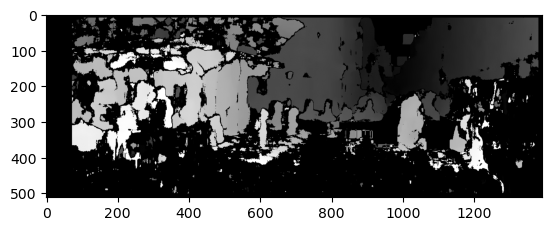

In [42]:
##################################
# Your code here
stereo = cv2.StereoBM.create(numDisparities=64, blockSize=21)
disparity = stereo.compute(imgL_rGray, imgR_rGray)
plt.imshow(disparity,'gray')
plt.show()

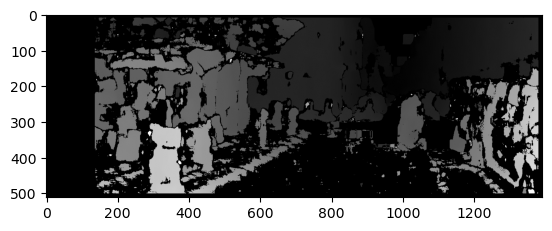

In [48]:
##################################
# Your code here
stereo = cv2.StereoBM.create(numDisparities=128, blockSize=21)
disparity = stereo.compute(imgL_rGray, imgR_rGray)
plt.imshow(disparity,'gray')
plt.show()

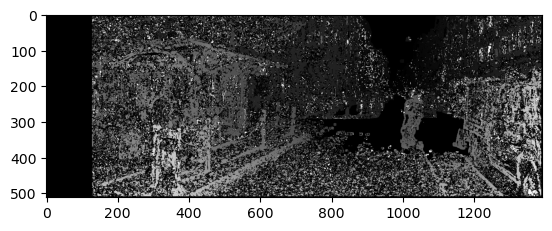

In [68]:
##################################
# Your code here
stereo = cv2.StereoBM.create(numDisparities=128, blockSize=5)
disparity = stereo.compute(imgL_rGray, imgR_rGray)
plt.imshow(disparity,'gray')
plt.show()

<font color='blue'>

# Questions

<font color='blue'>

**Question**: We started with numDisparities equal to 16. It seems that only the distant parts of the scene are detected well. Why is this?

Looking at the formula Z=fB/d, diparity (d) is inversely proportional to depth (Z). As the parameter numDisparities is increased, the figure for depth (Z) decreases and the distant objects are less well detected.

<font color='blue'>

**Question**: What configuration did you 'land on' that looked good? Can you explain the choice of parameters?

Purely using 'trial and error', numDisparities=128, blockSize=5 appeared to give the best combination of edge detection and depth. Making the 'block size' smaller gives higher resolution as the algorithm zooms in on smaller portions of the image. Increasing the value of numDisparities (d) increases the value of depth (Z) because of the inverse relationship already mentioned.

<font color='blue'>

**Question**: In the stereo disparity image, the road is not well detected, regardless of blockSize or numDisparities setting. Explain this.

This is because the road is a roughly horizontal plane stretching away from the camera in a perpendicular direction. This means that, at any given distance, all points on the road have nearly the same disparity.

<font color='blue'>

**Question**: If we display the disparity using the cmap='gray' option, then the disparity is displayed in grayscale. Larger distances in the image are brighter. Explain why it seems that closer objects are brighter.

Because of the relationship between the two cameras, the disparity is inversely proportional to the depth, as given by the formula Z=fB/d. So, the closer an object is to the camera, the larger its disparity will be. Conversely, objects that are farther away will have smaller disparities. This is because as an object moves further away from the camera, the difference in its position between the left and right images (the disparity) decreases. Therefore, by analyzing the disparity map, we can infer the relative depth of objects in the scene.   


<font color='blue'>

**Question**: Play around with the `blockSize` parameter, making it smaller and larger. What impact does it seem to have? Describe the tradeoff.

Making blockSize smaller increases the resolution of feeatures captured in the image, particularly edges. It results in more of the objects being made identifiable. I also observed that making blockSize larger resulted in 'blobs' being created with near objects and these 'blobs' being brighter in colour.